### Import Modules and Libraries

In [ ]:
from pathlib import Path
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

### Configure Data and Helper Functions

In [ ]:
# ============================================================
# CONFIG
# ============================================================

DATA_PATH = Path("/content/BTS_2024_top10_origin_combined.parquet")
OUT_DIR = Path("/content/capstone_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
CACHE_DIR = OUT_DIR / "cache"

for d in [OUT_DIR, FIG_DIR, TAB_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TOP10 = ["ATL", "DFW", "DEN", "ORD", "LAX", "JFK", "CLT", "LAS", "MCO", "MIA"]

AIRPORT_COORDS = {
    "ATL": (33.6407, -84.4277),
    "DFW": (32.8998, -97.0403),
    "DEN": (39.8561, -104.6737),
    "ORD": (41.9742, -87.9073),
    "LAX": (33.9416, -118.4085),
    "JFK": (40.6413, -73.7781),
    "CLT": (35.2144, -80.9473),
    "LAS": (36.0840, -115.1537),
    "MCO": (28.4312, -81.3081),
    "MIA": (25.7959, -80.2870),
}

WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"
WEATHER_VARS = [
    "weather_code",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "precipitation_hours",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "cloud_cover_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
]

LEAKAGE_COLS = [
    "DEP_TIME", "DEP_DELAY", "TAXI_OUT", "TAXI_IN", "ARR_TIME", "ARR_DELAY",
    "ARR_DEL15", "ACTUAL_ELAPSED_TIME", "AIR_TIME", "CARRIER_DELAY",
    "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",
    "CANCELLATION_CODE"
]

In [ ]:
# ============================================================
# HELPERS
# ============================================================

def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    h, m = divmod(x, 100)
    if h > 23 or m > 59:
        return np.nan
    return h * 60 + m

def save_table(df, name, show=True, max_rows=20):
    path = TAB_DIR / name
    df.to_csv(path, index=False)
    print(f"\nsaved: {path}")

    if show:
        if len(df) <= max_rows:
            display(df)
        else:
            display(df.head(max_rows))
            print(f"[showing first {max_rows} of {len(df)} rows]")

def save_fig(name, show=True):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    print(f"saved: {path}")

    if show:
        plt.show()
    else:
        plt.close()


def rolling_history(daily_df, group_cols, value_cols, windows=(14, 30, 60), prefix="grp"):
    #Build prior-history features from daily aggregates using lagged rolling windows to prevent direct leakage
    daily_df = daily_df.sort_values(group_cols + ["FLIGHT_DATE"]).copy()
    out = daily_df[group_cols + ["FLIGHT_DATE"]].copy()

    for col in value_cols:
        grouped = daily_df.groupby(group_cols, dropna=False)[col]

        out[f"{prefix}_{col}_lag1"] = grouped.shift(1)

        for w in windows:
            out[f"{prefix}_{col}_roll{w}"] = grouped.transform(
                lambda s: s.shift(1).rolling(w, min_periods=max(3, w // 4)).mean()
            )

    return out


def fetch_weather_for_airport(airport, start_date, end_date):
    cache_path = CACHE_DIR / f"weather_{airport}_{start_date}_{end_date}.parquet"
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    lat, lon = AIRPORT_COORDS[airport]
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ",".join(WEATHER_VARS),
        "timezone": "America/Chicago"
    }
    r = requests.get(WEATHER_URL, params=params, timeout=90)
    r.raise_for_status()
    payload = r.json()

    w = pd.DataFrame(payload["daily"])
    w["FLIGHT_DATE"] = pd.to_datetime(w["time"])
    w["ORIGIN"] = airport
    w = w.drop(columns="time")

    rename_map = {c: f"W_{c.upper()}" for c in w.columns if c not in ["FLIGHT_DATE", "ORIGIN"]}
    w = w.rename(columns=rename_map)

    w.to_parquet(cache_path, index=False)
    time.sleep(0.25)
    return w


### Load Data

In [ ]:
df = pd.read_parquet(DATA_PATH)
df.columns = [c.upper().strip() for c in df.columns]
df["ORIGIN"] = df["ORIGIN"].astype(str).str.upper()
df = df[df["ORIGIN"].isin(TOP10)].copy()

### Data Preprocessing & Cleaning

In [ ]:
num_cols = [
    "YEAR", "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK",
    "OP_CARRIER_AIRLINE_ID", "OP_CARRIER_FL_NUM",
    "ORIGIN_AIRPORT_ID", "DEST_AIRPORT_ID",
    "CRS_DEP_TIME", "CRS_ARR_TIME", "CRS_ELAPSED_TIME",
    "DISTANCE", "DEP_DEL15", "CANCELLED",
    "DEP_DELAY", "ARR_DELAY", "TAXI_OUT", "TAXI_IN"
]
present_num_cols = [c for c in num_cols if c in df.columns]
df[present_num_cols] = df[present_num_cols].apply(pd.to_numeric, errors="coerce")

df["FLIGHT_DATE"] = pd.to_datetime(
    dict(year=df["YEAR"], month=df["MONTH"], day=df["DAY_OF_MONTH"]),
    errors="coerce"
)

df["TARGET_DELAY15"] = pd.to_numeric(df["DEP_DEL15"], errors="coerce") if "DEP_DEL15" in df.columns else np.nan
df["TARGET_CANCELLED"] = pd.to_numeric(df["CANCELLED"], errors="coerce").fillna(0) if "CANCELLED" in df.columns else np.nan

if "CRS_DEP_TIME" in df.columns:
    df["CRS_DEP_MIN"] = df["CRS_DEP_TIME"].apply(hhmm_to_minutes)
    df["DEP_HOUR"] = (df["CRS_DEP_MIN"] // 60).astype("float")
    df["DEP_HOUR_SIN"] = np.sin(2 * np.pi * df["CRS_DEP_MIN"] / 1440)
    df["DEP_HOUR_COS"] = np.cos(2 * np.pi * df["CRS_DEP_MIN"] / 1440)

if "CRS_ARR_TIME" in df.columns:
    df["CRS_ARR_MIN"] = df["CRS_ARR_TIME"].apply(hhmm_to_minutes)

df["IS_WEEKEND"] = df["FLIGHT_DATE"].dt.dayofweek.isin([5, 6]).astype(int)
df["DAY_OF_YEAR"] = df["FLIGHT_DATE"].dt.dayofyear
df["QUARTER"] = df["FLIGHT_DATE"].dt.quarter
df["ROUTE"] = df["ORIGIN"].astype(str) + "_" + df["DEST"].astype(str)
df["CARRIER_ROUTE"] = (
    df["OP_CARRIER_AIRLINE_ID"].astype("Int64").astype(str) + "_" +
    df["ORIGIN"].astype(str) + "_" +
    df["DEST"].astype(str)
)

df["TAIL_NUM"] = df["TAIL_NUM"].astype("category")
df["ORIGIN"] = df["ORIGIN"].astype("category")
df["DEST"] = df["DEST"].astype("category")

In [ ]:
# ============================================================
# Merge Weather Data
# ============================================================

start_date = str(df["FLIGHT_DATE"].min().date())
end_date = str(df["FLIGHT_DATE"].max().date())

weather_frames = [fetch_weather_for_airport(a, start_date, end_date) for a in sorted(df["ORIGIN"].unique())]
weather = pd.concat(weather_frames, ignore_index=True)

if "W_PRECIPITATION_SUM" in weather.columns:
    weather["W_PRECIP_FLAG"] = (weather["W_PRECIPITATION_SUM"] > 0).astype(int)
if "W_SNOWFALL_SUM" in weather.columns:
    weather["W_SNOW_FLAG"] = (weather["W_SNOWFALL_SUM"] > 0).astype(int)
if "W_WIND_GUSTS_10M_MAX" in weather.columns:
    gust_cut = weather["W_WIND_GUSTS_10M_MAX"].quantile(0.90)
    weather["W_HIGH_WIND_FLAG"] = (weather["W_WIND_GUSTS_10M_MAX"] >= gust_cut).astype(int)
if "W_TEMPERATURE_2M_MIN" in weather.columns:
    weather["W_FREEZE_FLAG"] = (weather["W_TEMPERATURE_2M_MIN"] <= 0).astype(int)

#Lag weather data to mirror real-world limitation
weather = weather.sort_values(["ORIGIN", "FLIGHT_DATE"]).copy()
weather_cols = [c for c in weather.columns if c.startswith("W_")]
for c in ["W_PRECIPITATION_SUM", "W_SNOWFALL_SUM", "W_WIND_GUSTS_10M_MAX", "W_TEMPERATURE_2M_MEAN"]:
    if c in weather.columns:
        weather[f"{c}_LAG1"] = weather.groupby("ORIGIN")[c].shift(1)
        weather[f"{c}_ROLL7"] = (
            weather.groupby("ORIGIN")[c]
            .shift(1)
            .rolling(7, min_periods=3)
            .mean()
            .reset_index(level=0, drop=True)
        )

df = df.merge(weather, on=["ORIGIN", "FLIGHT_DATE"], how="left")

### Feature Engineering

In [ ]:
# Historical airport and route behavior
daily_origin = (
    df.groupby(["ORIGIN", "FLIGHT_DATE"], dropna=False)
      .agg(
          origin_daily_flights=("ORIGIN", "size"),
          origin_delay_rate=("TARGET_DELAY15", "mean"),
          origin_cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
)

origin_hist = rolling_history(
    daily_origin,
    group_cols=["ORIGIN"],
    value_cols=["origin_daily_flights", "origin_delay_rate", "origin_cancel_rate"],
    windows=(14, 30, 60),
    prefix="origin"
)
df = df.merge(origin_hist, on=["ORIGIN", "FLIGHT_DATE"], how="left")

daily_route = (
    df.groupby(["ROUTE", "FLIGHT_DATE"], dropna=False)
      .agg(
          route_daily_flights=("ROUTE", "size"),
          route_delay_rate=("TARGET_DELAY15", "mean"),
          route_cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
)

route_hist = rolling_history(
    daily_route,
    group_cols=["ROUTE"],
    value_cols=["route_daily_flights", "route_delay_rate", "route_cancel_rate"],
    windows=(14, 30, 60),
    prefix="route"
)
df = df.merge(route_hist, on=["ROUTE", "FLIGHT_DATE"], how="left")

daily_carrier_route = (
    df.groupby(["CARRIER_ROUTE", "FLIGHT_DATE"], dropna=False)
      .agg(
          carrier_route_daily_flights=("CARRIER_ROUTE", "size"),
          carrier_route_delay_rate=("TARGET_DELAY15", "mean"),
          carrier_route_cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
)

carrier_route_hist = rolling_history(
    daily_carrier_route,
    group_cols=["CARRIER_ROUTE"],
    value_cols=["carrier_route_daily_flights", "carrier_route_delay_rate", "carrier_route_cancel_rate"],
    windows=(14, 30, 60),
    prefix="carrier_route"
)
df = df.merge(carrier_route_hist, on=["CARRIER_ROUTE", "FLIGHT_DATE"], how="left")

In [ ]:

#Expanded history features
df = df.sort_values(["FLIGHT_DATE", "ORIGIN", "DEST"]).copy()

route_grp = df.groupby("ROUTE", dropna=False)
df["ROUTE_OBS_BEFORE"] = route_grp.cumcount()
df["ROUTE_DELAY_RATE_EXPANDING"] = route_grp["TARGET_DELAY15"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)
df["ROUTE_CANCEL_RATE_EXPANDING"] = route_grp["TARGET_CANCELLED"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)

carrier_route_grp = df.groupby("CARRIER_ROUTE", dropna=False)
df["CARRIER_ROUTE_OBS_BEFORE"] = carrier_route_grp.cumcount()
df["CARRIER_ROUTE_DELAY_RATE_EXPANDING"] = carrier_route_grp["TARGET_DELAY15"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)
df["CARRIER_ROUTE_CANCEL_RATE_EXPANDING"] = carrier_route_grp["TARGET_CANCELLED"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)

In [ ]:
# Aircraft sequence / propagation - gets previous flight by tail num

if "TAIL_NUM" in df.columns and df["TAIL_NUM"].notna().any():
    df["TAIL_NUM"] = df["TAIL_NUM"].astype("category")
    df["ORIGIN"] = df["ORIGIN"].astype("category")
    df["DEST"] = df["DEST"].astype("category")

    # Sort once
    sort_cols = ["TAIL_NUM", "FLIGHT_DATE"]
    if "CRS_DEP_MIN" in df.columns:
        sort_cols.append("CRS_DEP_MIN")

    df = df.sort_values(sort_cols).copy()
    tg = df.groupby("TAIL_NUM", sort=False, observed=True)

    if "DEST" in df.columns:
        df["TAIL_PREV_DEST"] = tg["DEST"].shift(1)

    df["TAIL_PREV_FLIGHT_DATE"] = tg["FLIGHT_DATE"].shift(1)

    if "DEP_DELAY" in df.columns:
        df["TAIL_PREV_DEP_DELAY"] = tg["DEP_DELAY"].shift(1)

    if "ARR_DELAY" in df.columns:
        df["TAIL_PREV_ARR_DELAY"] = tg["ARR_DELAY"].shift(1)

    if "CANCELLED" in df.columns:
        df["TAIL_PREV_CANCELLED"] = tg["CANCELLED"].shift(1)

    df["TAIL_PREV_DAYS_GAP"] = (df["FLIGHT_DATE"] - df["TAIL_PREV_FLIGHT_DATE"]).dt.days

    df["TAIL_PREV_DEST_MATCH_ORIGIN"] = (
    (df["TAIL_PREV_DEST"].astype("string") == df["ORIGIN"].astype("string")) &
    (df["TAIL_PREV_DAYS_GAP"] >= 1)).astype("int8")

    if "TAIL_PREV_ARR_DELAY" in df.columns:
        df["TAIL_PREV_ARR_DELAY_PRIOR"] = df["TAIL_PREV_ARR_DELAY"].where(df["TAIL_PREV_DAYS_GAP"] >= 1)

    if "TAIL_PREV_DEP_DELAY" in df.columns:
        df["TAIL_PREV_DEP_DELAY_PRIOR"] = df["TAIL_PREV_DEP_DELAY"].where(df["TAIL_PREV_DAYS_GAP"] >= 1)

    if "TAIL_PREV_CANCELLED" in df.columns:
        df["TAIL_PREV_CANCELLED_PRIOR"] = df["TAIL_PREV_CANCELLED"].where(df["TAIL_PREV_DAYS_GAP"] >= 1)

    # Tail-level rolling history
    # One row per TAIL_NUM + FLIGHT_DATE
    tail_daily = (
        df.loc[df["TAIL_NUM"].notna(), ["TAIL_NUM", "FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED"]]
          .groupby(["TAIL_NUM", "FLIGHT_DATE"], observed=True)
          .agg(
              TAIL_DELAY_RATE_DAILY=("TARGET_DELAY15", "mean"),
              TAIL_CANCEL_RATE_DAILY=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
          .sort_values(["TAIL_NUM", "FLIGHT_DATE"])
    )

    g_tail_daily = tail_daily.groupby("TAIL_NUM", sort=False, observed=True)

    tail_daily["TAIL_DELAY_RATE_ROLL30"] = g_tail_daily["TAIL_DELAY_RATE_DAILY"].transform(
        lambda s: s.shift(1).rolling(30, min_periods=5).mean()
    )
    tail_daily["TAIL_CANCEL_RATE_ROLL30"] = g_tail_daily["TAIL_CANCEL_RATE_DAILY"].transform(
        lambda s: s.shift(1).rolling(30, min_periods=5).mean()
    )

    df = df.merge(
        tail_daily[["TAIL_NUM", "FLIGHT_DATE", "TAIL_DELAY_RATE_ROLL30", "TAIL_CANCEL_RATE_ROLL30"]],
        on=["TAIL_NUM", "FLIGHT_DATE"],
        how="left"
    )

    del tail_daily


    # Predecessor-pattern rolling history
    # Keep only common patterns
    valid_prev = df["TAIL_PREV_DAYS_GAP"] >= 1

    prev_key = (
        df["TAIL_PREV_DEST"].astype("string") + "_" +
        df["ORIGIN"].astype("string") + "_" +
        df["DEST"].astype("string")
    )
    df["PREV_ORIGIN_DEST"] = prev_key.where(valid_prev)

    prev_counts = df["PREV_ORIGIN_DEST"].value_counts(dropna=True)
    supported_patterns = prev_counts[prev_counts >= 50].index

    prev_daily = (
        df.loc[df["PREV_ORIGIN_DEST"].isin(supported_patterns),
               ["PREV_ORIGIN_DEST", "FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED"]]
          .groupby(["PREV_ORIGIN_DEST", "FLIGHT_DATE"], observed=True)
          .agg(
              PREV_PATTERN_DELAY_DAILY=("TARGET_DELAY15", "mean"),
              PREV_PATTERN_CANCEL_DAILY=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
          .sort_values(["PREV_ORIGIN_DEST", "FLIGHT_DATE"])
    )

    if not prev_daily.empty:
        g_prev_daily = prev_daily.groupby("PREV_ORIGIN_DEST", sort=False, observed=True)

        prev_daily["PREV_PATTERN_DELAY_RATE_ROLL30"] = g_prev_daily["PREV_PATTERN_DELAY_DAILY"].transform(
            lambda s: s.shift(1).rolling(30, min_periods=5).mean()
        )
        prev_daily["PREV_PATTERN_CANCEL_RATE_ROLL30"] = g_prev_daily["PREV_PATTERN_CANCEL_DAILY"].transform(
            lambda s: s.shift(1).rolling(30, min_periods=5).mean()
        )

        df = df.merge(
            prev_daily[
                [
                    "PREV_ORIGIN_DEST",
                    "FLIGHT_DATE",
                    "PREV_PATTERN_DELAY_RATE_ROLL30",
                    "PREV_PATTERN_CANCEL_RATE_ROLL30",
                ]
            ],
            on=["PREV_ORIGIN_DEST", "FLIGHT_DATE"],
            how="left"
        )

        del prev_daily

    drop_temp = [
        "TAIL_PREV_DEST",
        "TAIL_PREV_FLIGHT_DATE",
        "TAIL_PREV_DEP_DELAY",
        "TAIL_PREV_ARR_DELAY",
        "TAIL_PREV_CANCELLED",
    ]
    drop_temp = [c for c in drop_temp if c in df.columns]
    df.drop(columns=drop_temp, inplace=True)

    for c in ["TAIL_PREV_DAYS_GAP", "TAIL_PREV_DEST_MATCH_ORIGIN"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], downcast="integer")


In [ ]:
if "DISTANCE" in df.columns:
    df["LOG_DISTANCE"] = np.log1p(df["DISTANCE"])

In [ ]:
for col in df.columns:
  print(col)

YEAR
MONTH
DAY_OF_MONTH
OP_CARRIER_AIRLINE_ID
TAIL_NUM
OP_CARRIER_FL_NUM
ORIGIN_AIRPORT_ID
ORIGIN
ORIGIN_CITY_NAME
DEST_AIRPORT_ID
DEST
DEST_CITY_NAME
DEP_TIME
DEP_DELAY
DEP_DEL15
TAXI_OUT
TAXI_IN
ARR_TIME
ARR_DELAY
ARR_DEL15
CANCELLED
ACTUAL_ELAPSED_TIME
AIR_TIME
DISTANCE
CARRIER_DELAY
WEATHER_DELAY
NAS_DELAY
SECURITY_DELAY
LATE_AIRCRAFT_DELAY
FLIGHT_DATE
TARGET_DELAY15
TARGET_CANCELLED
IS_WEEKEND
DAY_OF_YEAR
QUARTER
ROUTE
CARRIER_ROUTE
W_WEATHER_CODE
W_TEMPERATURE_2M_MEAN
W_TEMPERATURE_2M_MAX
W_TEMPERATURE_2M_MIN
W_PRECIPITATION_SUM
W_RAIN_SUM
W_SNOWFALL_SUM
W_PRECIPITATION_HOURS
W_WIND_SPEED_10M_MAX
W_WIND_GUSTS_10M_MAX
W_WIND_DIRECTION_10M_DOMINANT
W_CLOUD_COVER_MEAN
W_RELATIVE_HUMIDITY_2M_MEAN
W_SURFACE_PRESSURE_MEAN
W_PRECIP_FLAG
W_SNOW_FLAG
W_HIGH_WIND_FLAG
W_FREEZE_FLAG
W_PRECIPITATION_SUM_LAG1
W_PRECIPITATION_SUM_ROLL7
W_SNOWFALL_SUM_LAG1
W_SNOWFALL_SUM_ROLL7
W_WIND_GUSTS_10M_MAX_LAG1
W_WIND_GUSTS_10M_MAX_ROLL7
W_TEMPERATURE_2M_MEAN_LAG1
W_TEMPERATURE_2M_MEAN_ROLL7
origin_orig

In [ ]:
df.head()

,YEAR,MONTH,DAY_OF_MONTH,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,...,TAIL_PREV_DEST_MATCH_ORIGIN,TAIL_PREV_ARR_DELAY_PRIOR,TAIL_PREV_DEP_DELAY_PRIOR,TAIL_PREV_CANCELLED_PRIOR,TAIL_DELAY_RATE_ROLL30,TAIL_CANCEL_RATE_ROLL30,PREV_ORIGIN_DEST,PREV_PATTERN_DELAY_RATE_ROLL30,PREV_PATTERN_CANCEL_RATE_ROLL30,LOG_DISTANCE
0,2024,3,14,20368,188NV,581.0,12889,LAS,"Las Vegas, NV",11986,...,0,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,7.404279
1,2024,3,15,20368,188NV,564.0,12889,LAS,"Las Vegas, NV",11986,...,0,2.0,24.0,0.0,NaN,NaN,GRR_LAS_GRR,0.160000,0.0,7.404279
2,2024,3,17,20368,188NV,581.0,12889,LAS,"Las Vegas, NV",11986,...,0,178.0,178.0,0.0,NaN,NaN,GRR_LAS_GRR,0.192308,0.0,7.404279
3,2024,5,16,20368,188NV,1561.0,11292,DEN,"Denver, CO",10408,...,0,-5.0,-5.0,0.0,NaN,NaN,GRR_DEN_ATW,NaN,NaN,6.784457
4,2024,5,19,20368,188NV,3202.0,12889,LAS,"Las Vegas, NV",10408,...,0,-47.0,-25.0,0.0,NaN,NaN,ATW_LAS_ATW,0.233333,0.0,7.320527


### Exploratory Data Analysis

In [ ]:
quality = pd.DataFrame({
    "column": df.columns,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "dtype": df.dtypes.astype(str).values
}).sort_values("missing_pct", ascending=False)

save_table(quality, "missingness.csv", show=False, max_rows=30)

summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "date_min",
        "date_max",
        "n_origins",
        "n_destinations",
        "n_routes",
        "n_carriers",
        "delay_rate_non_missing",
        "cancel_rate"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["FLIGHT_DATE"].min(),
        df["FLIGHT_DATE"].max(),
        df["ORIGIN"].nunique(),
        df["DEST"].nunique(),
        df["ROUTE"].nunique(),
        df["OP_CARRIER_AIRLINE_ID"].nunique(),
        df["TARGET_DELAY15"].mean(skipna=True),
        df["TARGET_CANCELLED"].mean(skipna=True)
    ]
})

save_table(summary, "dataset_summary.csv", show=True)


saved: /content/capstone_outputs/tables/missingness.csv

saved: /content/capstone_outputs/tables/dataset_summary.csv


,metric,value
0,rows,2237913
1,columns,116
2,date_min,2024-01-01 00:00:00
3,date_max,2024-12-31 00:00:00
4,n_origins,10
5,n_destinations,287
6,n_routes,1316
7,n_carriers,15
8,delay_rate_non_missing,0.231707
9,cancel_rate,0.013328



saved: /content/capstone_outputs/tables/monthly_disruption.csv


,MONTH,flights,delay_rate,cancel_rate
0,1,174096,0.253701,0.031230
1,2,165171,0.173857,0.004202
2,3,187004,0.236183,0.010433
3,4,185013,0.212630,0.007124
4,5,194296,0.297585,0.016923
5,6,192113,0.288263,0.013633
6,7,197874,0.340602,0.029857
7,8,194124,0.264579,0.017746
8,9,184480,0.171615,0.005513
9,10,194961,0.148215,0.010258


saved: /content/capstone_outputs/figures/monthly_disruption_rates.png


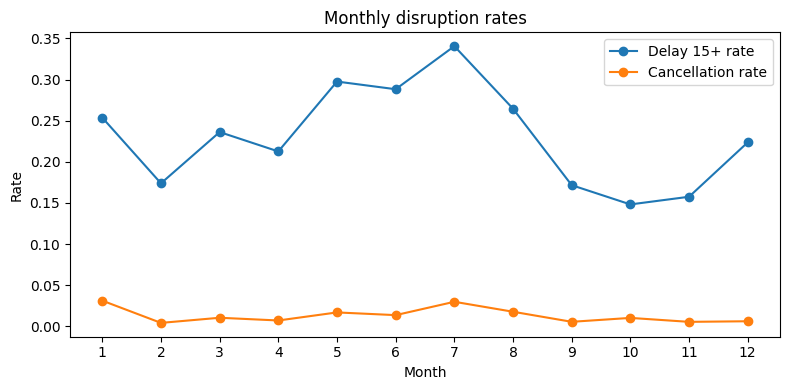

In [ ]:
# Monthly disruption trends
monthly = (
    df.groupby("MONTH")
      .agg(
          flights=("MONTH", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
      .sort_values("MONTH")
)

save_table(monthly, "monthly_disruption.csv", show=True)

plt.figure(figsize=(8, 4))
plt.plot(monthly["MONTH"], monthly["delay_rate"], marker="o", label="Delay 15+ rate")
plt.plot(monthly["MONTH"], monthly["cancel_rate"], marker="o", label="Cancellation rate")
plt.title("Monthly disruption rates")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.xticks(monthly["MONTH"])
plt.legend()
save_fig("monthly_disruption_rates.png", show=True)


saved: /content/capstone_outputs/tables/disruption_by_actual_departure_hour.csv


,ACTUAL_DEP_HOUR,flights,delay_rate,cancel_rate
0,0,16127,0.635828,0.003038
1,1,5289,0.784836,0.002836
2,2,1084,0.986162,0.003690
3,3,259,1.000000,0.000000
4,4,5676,0.034884,0.000000
5,5,49293,0.037308,0.000101
6,6,78865,0.057617,0.000152
7,7,119799,0.077196,0.000142
8,8,159135,0.089776,0.000339
9,9,144167,0.139986,0.000208


saved: /content/capstone_outputs/figures/delay_by_actual_departure_hour.png


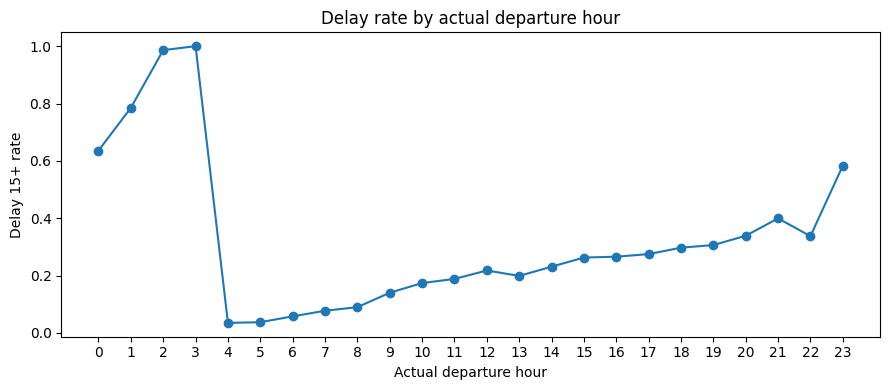


saved: /content/capstone_outputs/tables/disruption_by_day_of_week.csv


,DAY_NAME,flights,delay_rate,cancel_rate
0,Monday,337157,0.232037,0.012324
1,Tuesday,308792,0.202434,0.011636
2,Wednesday,307707,0.203685,0.012177
3,Thursday,327089,0.236836,0.015809
4,Friday,330938,0.253867,0.015127
5,Saturday,295858,0.234965,0.012330
6,Sunday,330372,0.254774,0.013639


saved: /content/capstone_outputs/figures/delay_by_day_of_week.png


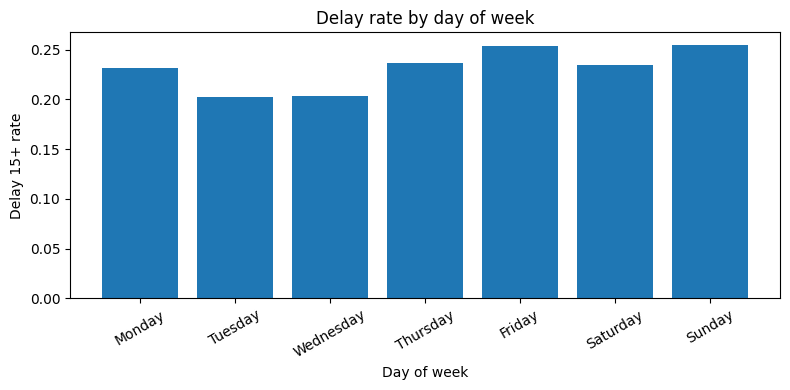

In [ ]:
# Temporal patterns

if "DEP_TIME" in df.columns:
    dep_time_numeric = pd.to_numeric(df["DEP_TIME"], errors="coerce")
    df["ACTUAL_DEP_HOUR"] = ((dep_time_numeric // 100) % 24).astype("Int64")

    by_hour = (
        df.loc[df["ACTUAL_DEP_HOUR"].notna()]
          .groupby("ACTUAL_DEP_HOUR", observed=True)
          .agg(
              flights=("ACTUAL_DEP_HOUR", "size"),
              delay_rate=("TARGET_DELAY15", "mean"),
              cancel_rate=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
          .sort_values("ACTUAL_DEP_HOUR")
    )

    save_table(by_hour, "disruption_by_actual_departure_hour.csv", show=True, max_rows=24)

    plt.figure(figsize=(9, 4))
    plt.plot(by_hour["ACTUAL_DEP_HOUR"], by_hour["delay_rate"], marker="o")
    plt.title("Delay rate by actual departure hour")
    plt.xlabel("Actual departure hour")
    plt.ylabel("Delay 15+ rate")
    plt.xticks(range(0, 24))
    save_fig("delay_by_actual_departure_hour.png", show=True)

dow = (
    df.assign(DAY_NAME=df["FLIGHT_DATE"].dt.day_name())
      .groupby("DAY_NAME", observed=True)
      .agg(
          flights=("ORIGIN", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
      .reset_index()
)

save_table(dow, "disruption_by_day_of_week.csv", show=True)

plt.figure(figsize=(8, 4))
plt.bar(dow["DAY_NAME"], dow["delay_rate"])
plt.title("Delay rate by day of week")
plt.xlabel("Day of week")
plt.ylabel("Delay 15+ rate")
plt.xticks(rotation=30)
save_fig("delay_by_day_of_week.png", show=True)


saved: /content/capstone_outputs/tables/airport_disruption_summary.csv


/tmp/ipykernel_14727/3066523059.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ORIGIN")


,ORIGIN,flights,delay_rate,cancel_rate,avg_precip,avg_wind_gust
0,ATL,341910,0.197532,0.009973,3.901202,35.609742
3,DFW,313582,0.275268,0.018614,3.163220,37.262877
2,DEN,308645,0.231886,0.011291,1.020602,37.737418
9,ORD,280052,0.221815,0.013515,2.776616,39.633123
1,CLT,217574,0.264603,0.013683,3.154579,34.173747
6,LAX,194053,0.180403,0.008147,1.009273,38.565064
5,LAS,189252,0.235556,0.008824,0.280477,36.010763
7,MCO,159553,0.245677,0.018238,4.000754,35.183360
4,JFK,123348,0.202256,0.018590,3.130068,42.469779
8,MIA,109944,0.271532,0.017081,5.133541,37.119751


saved: /content/capstone_outputs/figures/delay_rate_by_origin.png


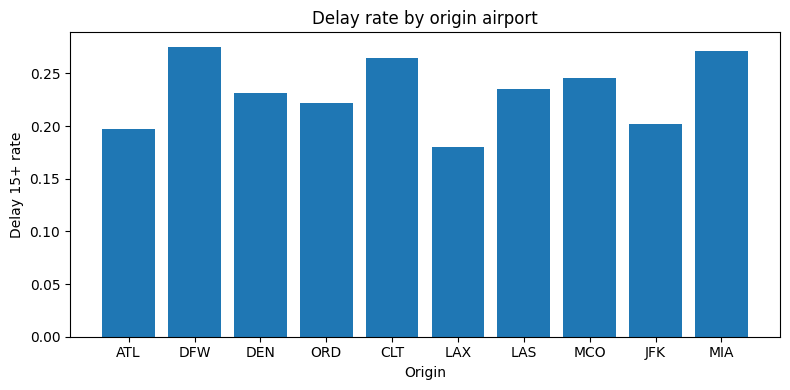

In [ ]:
# Airport disruption summary
airport = (
    df.groupby("ORIGIN")
      .agg(
          flights=("ORIGIN", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean"),
          avg_precip=("W_PRECIPITATION_SUM", "mean") if "W_PRECIPITATION_SUM" in df.columns else ("ORIGIN", "size"),
          avg_wind_gust=("W_WIND_GUSTS_10M_MAX", "mean") if "W_WIND_GUSTS_10M_MAX" in df.columns else ("ORIGIN", "size")
      )
      .reset_index()
      .sort_values("flights", ascending=False)
)

save_table(airport, "airport_disruption_summary.csv", show=True)

plt.figure(figsize=(8, 4))
plt.bar(airport["ORIGIN"], airport["delay_rate"])
plt.title("Delay rate by origin airport")
plt.xlabel("Origin")
plt.ylabel("Delay 15+ rate")
save_fig("delay_rate_by_origin.png", show=True)


saved: /content/capstone_outputs/tables/weather_delay_correlations.csv


,weather_feature,corr_with_delay
0,W_PRECIPITATION_SUM,0.099288
1,W_WIND_GUSTS_10M_MAX,0.052256
2,W_TEMPERATURE_2M_MEAN,0.053747
3,W_CLOUD_COVER_MEAN,0.064821



saved: /content/capstone_outputs/tables/delay_by_precip_bin.csv


,PRECIP_BIN,flights,delay_rate,cancel_rate
0,none,1320373,0.197161,0.006453
1,light,455343,0.243155,0.011659
2,moderate,281097,0.298084,0.019947
3,heavy,181100,0.359594,0.057366


saved: /content/capstone_outputs/figures/delay_by_precip_bin.png


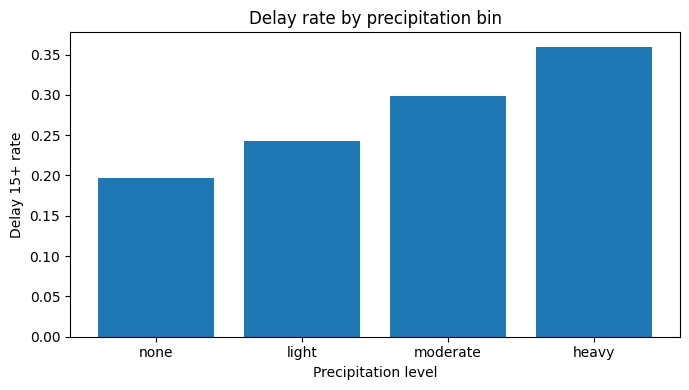


saved: /content/capstone_outputs/tables/delay_by_wind_gust_bin.csv


,GUST_BIN,flights,delay_rate,cancel_rate
0,"(11.499, 28.8]",581531,0.209237,0.010601
1,"(28.8, 36.0]",544811,0.219059,0.009113
2,"(36.0, 43.9]",554564,0.242622,0.014271
3,"(43.9, 117.7]",557007,0.256938,0.019357


In [ ]:
# Weather relationships
weather_delay = []
for c in ["W_PRECIPITATION_SUM", "W_WIND_GUSTS_10M_MAX", "W_TEMPERATURE_2M_MEAN", "W_CLOUD_COVER_MEAN"]:
    if c in df.columns:
        corr = df[[c, "TARGET_DELAY15"]].corr(numeric_only=True).iloc[0, 1]
        weather_delay.append([c, corr])

weather_delay = pd.DataFrame(weather_delay, columns=["weather_feature", "corr_with_delay"])
save_table(weather_delay, "weather_delay_correlations.csv", show=True)

if "W_PRECIPITATION_SUM" in df.columns:
    precip_bins = pd.cut(
        df["W_PRECIPITATION_SUM"],
        bins=[-0.01, 0, 2, 10, np.inf],
        labels=["none", "light", "moderate", "heavy"]
    )

    precip_delay = (
        df.assign(PRECIP_BIN=precip_bins)
          .groupby("PRECIP_BIN", observed=False)
          .agg(
              flights=("PRECIP_BIN", "size"),
              delay_rate=("TARGET_DELAY15", "mean"),
              cancel_rate=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
    )

    save_table(precip_delay, "delay_by_precip_bin.csv", show=True)

    plt.figure(figsize=(7, 4))
    plt.bar(precip_delay["PRECIP_BIN"].astype(str), precip_delay["delay_rate"])
    plt.title("Delay rate by precipitation bin")
    plt.xlabel("Precipitation level")
    plt.ylabel("Delay 15+ rate")
    save_fig("delay_by_precip_bin.png", show=True)

if "W_WIND_GUSTS_10M_MAX" in df.columns:
    gust_bins = pd.qcut(df["W_WIND_GUSTS_10M_MAX"], q=4, duplicates="drop")
    gust_delay = (
        df.assign(GUST_BIN=gust_bins)
          .groupby("GUST_BIN", observed=False)
          .agg(
              flights=("GUST_BIN", "size"),
              delay_rate=("TARGET_DELAY15", "mean"),
              cancel_rate=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
    )

    save_table(gust_delay, "delay_by_wind_gust_bin.csv", show=True)




saved: /content/capstone_outputs/tables/top_routes_summary.csv


,ROUTE,flights,delay_rate,cancel_rate
959,LAX_SFO,11526,0.259081,0.009023
1243,ORD_LGA,10969,0.223915,0.020604
689,JFK_LAX,9915,0.150359,0.003933
910,LAX_JFK,9915,0.170060,0.004438
912,LAX_LAS,9603,0.233477,0.009060
791,LAS_LAX,9559,0.235610,0.007741
419,DEN_PHX,9446,0.241014,0.010692
978,MCO_ATL,8967,0.242500,0.015278
87,ATL_MCO,8935,0.261601,0.016228
762,LAS_DEN,8192,0.227767,0.012207


saved: /content/capstone_outputs/figures/top_delay_routes.png


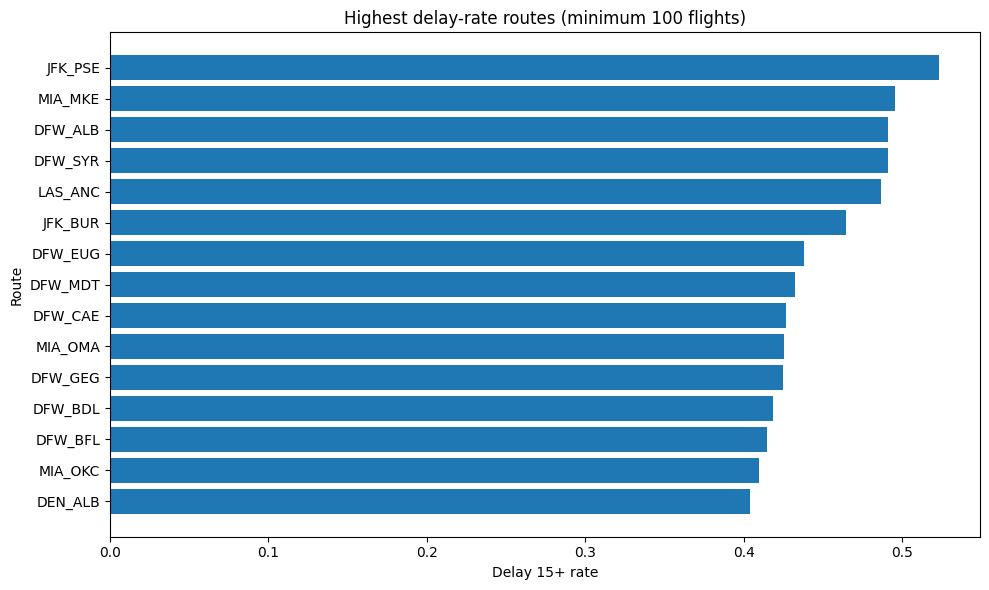


saved: /content/capstone_outputs/tables/historical_feature_correlations.csv


,feature,corr_with_delay
4,carrier_route_carrier_route_delay_rate_roll14,0.205431
5,carrier_route_carrier_route_delay_rate_roll30,0.200083
2,route_route_delay_rate_roll14,0.177613
3,route_route_delay_rate_roll30,0.168462
7,CARRIER_ROUTE_DELAY_RATE_EXPANDING,0.158206
0,origin_origin_delay_rate_roll14,0.154124
8,TAIL_DELAY_RATE_ROLL30,0.140967
1,origin_origin_delay_rate_roll30,0.137420
9,PREV_PATTERN_DELAY_RATE_ROLL30,0.123294
6,ROUTE_DELAY_RATE_EXPANDING,0.117790


saved: /content/capstone_outputs/figures/historical_feature_correlations.png


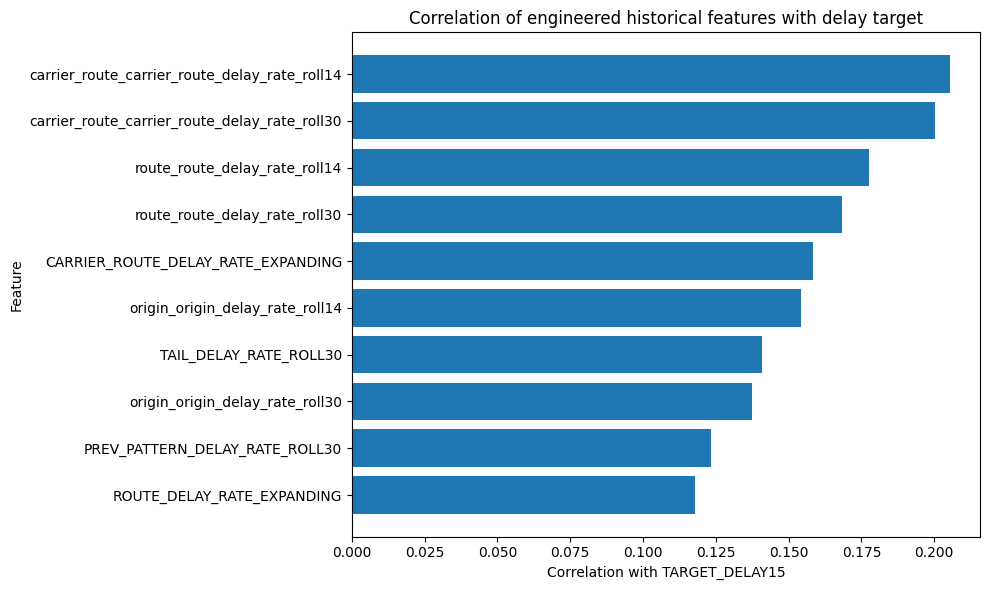

In [ ]:
# Route concentration / historical patterns


top_routes = (
    df.groupby("ROUTE", observed=True)
      .agg(
          flights=("ROUTE", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
      .sort_values("flights", ascending=False)
      .head(25)
)

save_table(top_routes, "top_routes_summary.csv", show=True, max_rows=25)

# Route delay figure: use meaningful-volume routes only, then show the 15 highest delay rates
route_plot = (
    df.groupby("ROUTE", observed=True)
      .agg(
          flights=("ROUTE", "size"),
          delay_rate=("TARGET_DELAY15", "mean")
      )
      .reset_index()
)

route_plot = route_plot[route_plot["flights"] >= 100].copy()
route_plot = route_plot.sort_values(["delay_rate", "flights"], ascending=[False, False]).head(15)

if not route_plot.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(route_plot["ROUTE"], route_plot["delay_rate"])
    plt.gca().invert_yaxis()
    plt.title("Highest delay-rate routes (minimum 100 flights)")
    plt.xlabel("Delay 15+ rate")
    plt.ylabel("Route")
    save_fig("top_delay_routes.png", show=True)

hist_cols_for_review = [
    "origin_origin_delay_rate_roll14",
    "origin_origin_delay_rate_roll30",
    "route_route_delay_rate_roll14",
    "route_route_delay_rate_roll30",
    "carrier_route_carrier_route_delay_rate_roll14",
    "carrier_route_carrier_route_delay_rate_roll30",
    "ROUTE_DELAY_RATE_EXPANDING",
    "CARRIER_ROUTE_DELAY_RATE_EXPANDING",
    "TAIL_DELAY_RATE_ROLL30",
    "PREV_PATTERN_DELAY_RATE_ROLL30"
]
hist_cols_for_review = [c for c in hist_cols_for_review if c in df.columns]

hist_corr = []
for c in hist_cols_for_review:
    tmp = df[[c, "TARGET_DELAY15"]].dropna()
    if not tmp.empty:
        corr = tmp.corr(numeric_only=True).iloc[0, 1]
        hist_corr.append([c, corr])

hist_corr = (
    pd.DataFrame(hist_corr, columns=["feature", "corr_with_delay"])
      .sort_values("corr_with_delay", ascending=False)
)

save_table(hist_corr, "historical_feature_correlations.csv", show=True, max_rows=30)

if not hist_corr.empty:
    hist_corr_plot = hist_corr.sort_values("corr_with_delay", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(hist_corr_plot["feature"], hist_corr_plot["corr_with_delay"])
    plt.title("Correlation of engineered historical features with delay target")
    plt.xlabel("Correlation with TARGET_DELAY15")
    plt.ylabel("Feature")
    save_fig("historical_feature_correlations.png", show=True)